# Lab 9 (Week 2 — Lab 4): Model Evaluation & Metrics

**Name:** Numair Fahad

**Role:** AI/ML Intern

**Company:** Zynvex Solutions

**GitHub:** https://github.com/numair-2003/AIML-Internship-NumairFahad

Welcome to Lab 9! So far you've measured your classifiers using accuracy alone. In this lab you'll go deeper: confusion matrices, precision, recall, F1-score, ROC curves, and cross-validation.

**For detailed theory on each metric, see the Lab 9 PDF and Learning Resources.**

This notebook focuses on the practical, hands-on workflow.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.

## Getting the Dataset

This lab uses the Titanic dataset. It loads directly from a URL — no download or upload needed.

In [1]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.shape)
print(df["Survived"].value_counts())   # notice the class imbalance
df.head()

(891, 12)
Survived
0    549
1    342
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Quick Preparation

A short cleanup before modeling: fill missing `Age` with the median, encode `Sex` as 0/1, and select a handful of relevant features. (Full data cleaning was covered in Lab 3 — here we keep it minimal since the focus is evaluation.)

In [2]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = df[features]
y = df["Survived"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model trained. Test accuracy:", model.score(X_test, y_test))

Model trained. Test accuracy: 0.8100558659217877


## Example 1: Confusion Matrix

[[92 13]
 [21 53]]


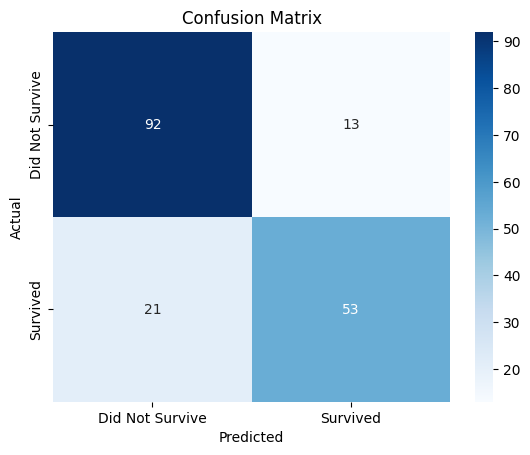

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Did Not Survive", "Survived"], yticklabels=["Did Not Survive", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Example 2: Precision, Recall & F1-Score

In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred))

Precision: 0.80
Recall: 0.72
F1-Score: 0.76

Full classification report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Example 3: ROC Curve & AUC

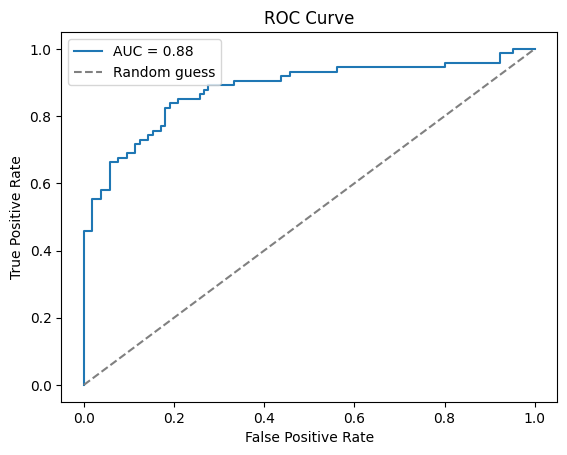

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Example 4: Cross-Validation

In [6]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
print("Accuracy for each of the 5 folds:", cv_scores)
print("Average accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Accuracy for each of the 5 folds: [0.7877095  0.7752809  0.78089888 0.75842697 0.82022472]
Average accuracy: 0.7845081915761722
Standard deviation: 0.020319050642552603


## Practice Exercise 1: Evaluate a Different Model

**Exercise:** Train a Decision Tree classifier (`max_depth=4`) on the same `X_train`, `y_train`. Compute and print its precision, recall, and F1-score on the test set. How do these compare to Logistic Regression?

In [7]:
### YOUR CODE HERE ###
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
### END ###

print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1-Score:", f1_tree)

Precision: 0.796875
Recall: 0.6891891891891891
F1-Score: 0.7391304347826086


## Practice Exercise 2: Changing the Decision Threshold

By default, a probability >= 0.5 is classified as the positive class. Lowering this threshold increases recall (catches more positives) but usually decreases precision.

**Exercise:** Using `y_probs` from Example 3, create new predictions using a threshold of 0.3 instead of 0.5, then compute the new precision and recall. Compare them to the original (threshold 0.5) values from Example 2.

In [8]:
### YOUR CODE HERE ###
y_pred_threshold_03 = (y_probs >= 0.3).astype(int)

precision_03 = precision_score(y_test, y_pred_threshold_03)
recall_03 = recall_score(y_test, y_pred_threshold_03)
### END ###

print("Precision (threshold=0.3):", precision_03)
print("Recall (threshold=0.3):", recall_03)

Precision (threshold=0.3): 0.7032967032967034
Recall (threshold=0.3): 0.8648648648648649


### **Threshold 0.3 vs Threshold 0.5 Values**

- **Recall** (**sensitivity**) **increased** from **0.72** to approximately **0.86**, which means that the model now captures **more actual survivors**.

- **Precision** **decreased** from **0.80** to approximately **0.70**, which indicates **more false positives**, i.e. people predicted to survive who did not.


## Practice Exercise 3: Cross-Validation with a Different Model

**Exercise:** Run 5-fold cross-validation on a Decision Tree (`max_depth=4`) instead of Logistic Regression, using the same `X` and `y`. Print the average accuracy and compare it to the Logistic Regression cross-validation score from Example 4.

In [14]:
### YOUR CODE HERE ###
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

tree_cv = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_cv_scores = cross_val_score(tree_cv, X, y, cv=5, scoring="accuracy")

print("Accuracy for each of the 5 folds of a Decision Tree (max_depth=4): ", tree_cv_scores)
print("\nAverage accuracy of a Decision Tree (max_depth=4): ", tree_cv_scores.mean())
print("\nStandard deviation of a Decision Tree (max_depth=4): ", tree_cv_scores.std())
### END ###

Accuracy for each of the 5 folds of a Decision Tree (max_depth=4):  [0.75977654 0.8258427  0.80898876 0.78651685 0.84269663]

Average accuracy of a Decision Tree (max_depth=4):  0.8047642960266147

Standard deviation of a Decision Tree (max_depth=4):  0.029181756869796648


### **Decision Tree Cross-Validation vs Logistic Regression Cross-Validation**

The **Decision Tree** model has a **higher average accuracy** than the Logistic Regression model (**0.80** vs **0.78**), but the **Logistic Regression** model is **more consistent across folds** because it has a **lower standard deviation**.

## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Full Evaluation**: For your Logistic Regression model, print the confusion matrix, precision, recall, F1-score, and AUC in one organized cell.
2. **Model Comparison**: Train Logistic Regression, KNN (k=5), and a Decision Tree (max_depth=4) on this dataset. Create a summary table comparing their precision, recall, and F1-score.
3. **Threshold Analysis**: Try 3 different thresholds (e.g., 0.3, 0.5, 0.7) on your Logistic Regression model's probabilities. For each, print precision and recall, and explain the trade-off you observe.
4. **Cross-Validation Comparison**: Run 5-fold cross-validation for all three models from Task 2, and report which model has the most consistent (lowest standard deviation) performance across folds.
5. **Reflection**: In a markdown cell, write 3-4 sentences on which metric (precision, recall, or F1) you think matters most for predicting Titanic survival, and why.

Confusion Matrix for Logistic Regression:
 [[92 13]
 [21 53]]


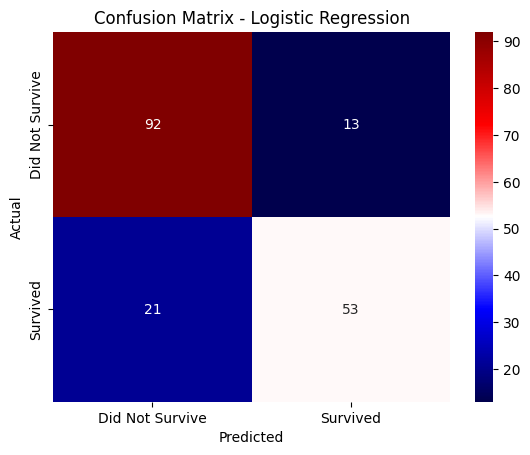

Precision for Logistic Regression: 0.8030
Recall for Logistic Regression: 0.7162
F1-Score for Logistic Regression: 0.7571
AUC Score for Logistic Regression: 0.8803


In [18]:
# Task 1
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred)
print("Confusion Matrix for Logistic Regression:\n", cm_lr)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="seismic", xticklabels=["Did Not Survive", "Survived"], yticklabels=["Did Not Survive", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

precision_lr = precision_score(y_test, y_pred)
recall_lr = recall_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)

print(f"Precision for Logistic Regression: {precision_lr:.4f}")
print(f"Recall for Logistic Regression: {recall_lr:.4f}")
print(f"F1-Score for Logistic Regression: {f1_lr:.4f}")

y_probs_lr = model.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_probs_lr)

print(f"AUC Score for Logistic Regression: {auc_lr:.4f}")

In [29]:
# Task 2
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

y_pred_lr = model.predict(X_test)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

tree_mod = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_mod.fit(X_train, y_train)
y_pred_tree = tree_mod.predict(X_test)

comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN (k=5)", "Decision Tree (max_depth=4)"],
    "Precision-Score": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_tree)
    ],
    "Recall-Score": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_tree)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_tree)
    ]
})

print(comparison_table.round(4))

                         Model  Precision-Score  Recall-Score  F1-Score
0          Logistic Regression           0.8030        0.7162    0.7571
1                    KNN (k=5)           0.6500        0.5270    0.5821
2  Decision Tree (max_depth=4)           0.7969        0.6892    0.7391


In [28]:
# Task 3
y_probs = model.predict_proba(X_test)[:, 1]

thresholds = [0.3, 0.5, 0.7]

print("Threshold    Precision   Recall")

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    prec_lr = precision_score(y_test, y_pred_t)
    rec_lr = recall_score(y_test, y_pred_t)

    print(f"   {t:.1f}     |  {prec_lr:.4f}   | {rec_lr:.4f}")

Threshold    Precision   Recall
   0.3     |  0.7033   | 0.8649
   0.5     |  0.8030   | 0.7162
   0.7     |  0.9512   | 0.5270


### **Observed Trade-off**

- As the **threshold increases** from **0.3** to **0.5** and then to **0.7**, **precision increases** approximately from **0.703** to **0.803** to **0.951**, whereas **recall decreases** approximately from **0.865** to **0.716** to **0.527**.

- A **lower threshold** classifies **more passengers** as **survivors**, i.e. achieves a **higher recall score**, yet catches **more false positives**.

- A **higher threshold** is considered **more conservative**, i.e. achieves a **higher precision**, but **misses more actual survivors**.

In [32]:
# Task 4
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree (max_depth=4)": DecisionTreeClassifier(max_depth=4, random_state=42)
}

print("Model                         | Mean Accuracy | Std Dev")

results = {}
for name, m in models.items():
    cv_scores = cross_val_score(m, X, y, cv=5, scoring="accuracy")
    mean_accuracy = cv_scores.mean()
    std_accuracy = cv_scores.std()
    results[name] = std_accuracy
    print(f"{name:30}| {mean_accuracy:.4f}        | {std_accuracy:.4f}")

most_consistent_model = min(results, key=results.get)

print(f"\nMost consistent model with lowest standard deviation: {most_consistent_model}")

Model                         | Mean Accuracy | Std Dev
Logistic Regression           | 0.7845        | 0.0203
KNN (k=5)                     | 0.6914        | 0.0341
Decision Tree (max_depth=4)   | 0.8048        | 0.0292

Most consistent model with lowest standard deviation: Logistic Regression


## **Task 5**

For predicting Titanic passengers' survival, **recall** is observed as the most significant metric because missing a passenger who actually survived (**false negative**) means that the model failed to identify the passenger who truly survived, which is considered costly in a life-and-death context. Although precision is also useful as well as F1-score providing a balanced view in such cases where the dataset is imbalanced (i.e. more passengers died than survived), the priority should be given to catching as many actual survivors as possible.  



In [33]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/numair-2003/AIML-Internship-NumairFahad.git

Mounted at /content/drive
Cloning into 'AIML-Internship-NumairFahad'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 93 (delta 43), reused 46 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (93/93), 1.38 MiB | 16.82 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/Lab 09_NumairFahad.ipynb" "/content/AIML-Internship-NumairFahad/"